# Ticket 2 — Model Development
### Team 2 — GenAI Project: Disease Prediction + AI Recipe Recommendation

**Team Lead:** Milan TJ | **Contributor:** Sona Santhosh, Ajul N D, Nandhana Venugopal | **Sprint Deadline:** 09 Jul 2026

---

## Goal

The objective of Ticket 2 is to develop and evaluate multiple Machine Learning classification models using the cleaned symptom dataset prepared in Ticket 1. Each model is trained on the processed symptom features and evaluated using standard performance metrics such as accuracy, precision, recall, and F1-score. The best-performing model is selected for deployment in Ticket 3, where it will be integrated into the Flask-based web application for disease prediction and AI-powered health recipe recommendation.

# 1. Setup & Imports

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure Project Directory

The current working directory is identified and the data folder is configured. This allows the notebook to access the training and testing datasets stored inside the project directory.

In [13]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"

print("Current Working Directory :", BASE_DIR)
print("Data Directory :", DATA_DIR)

Current Working Directory : C:\Users\HP\disease-prediction-system
Data Directory : C:\Users\HP\disease-prediction-system\data


## 3. Load the Prepared Dataset

The cleaned training and testing datasets generated during Ticket 1 are loaded into the notebook. These datasets contain symptom features and the corresponding disease labels (`prognosis`). Any unnecessary columns are removed before proceeding with model development.

In [14]:
# Load training and testing datasets

train_df = pd.read_csv(DATA_DIR / "Training.csv")
test_df = pd.read_csv(DATA_DIR / "Testing.csv")

# Remove unwanted column if it exists
train_df.drop(columns=["Unnamed: 133"], errors="ignore", inplace=True)
test_df.drop(columns=["Unnamed: 133"], errors="ignore", inplace=True)

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (4920, 133)
Testing Dataset Shape  : (42, 133)


## 4. Display the Training Dataset

To verify that the dataset has been loaded correctly, the first five rows of the training dataset are displayed. This helps confirm that all symptom features and the target column are available.

In [15]:
# Display first five rows

train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 5. Feature Selection

The dataset consists of binary symptom indicators that serve as the input features for disease prediction. The **prognosis** column represents the target variable (disease). In this step, the input features (`X`) and target labels (`y`) are separated for model training.

In [16]:
# Separate input features and target variable

X = train_df.drop(columns=["prognosis"])
y = train_df["prognosis"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (4920, 132)
Target Variable Shape: (4920,)


## 6. Label Encoding

In [17]:
# Encode disease labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Disease Classes:", len(label_encoder.classes_))
print("\nFirst 10 Encoded Labels:")
print(y_encoded[:10])

Number of Disease Classes: 41

First 10 Encoded Labels:
[15 15 15 15 15 15 15 15 15 15]


## 7. Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

An 80:20 split is used with a fixed random state to ensure reproducibility of the results.

In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (3936, 132)
Testing Features Shape  : (984, 132)
Training Labels Shape   : (3936,)
Testing Labels Shape    : (984,)


## 8. Model Development

Multiple machine learning classification algorithms are trained using the training dataset. Each model is evaluated using the testing dataset, and their performances are compared to identify the most suitable model for disease prediction.

The following algorithms are implemented:

- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Gaussian Naive Bayes
- Logistic Regression

## 8.1 Decision Tree Classifier


In [19]:
# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy :", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy : 100.0 %


### Decision Tree Classification Report

The classification report provides detailed evaluation metrics including precision, recall, F1-score, and overall accuracy for the Decision Tree model.

In [20]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

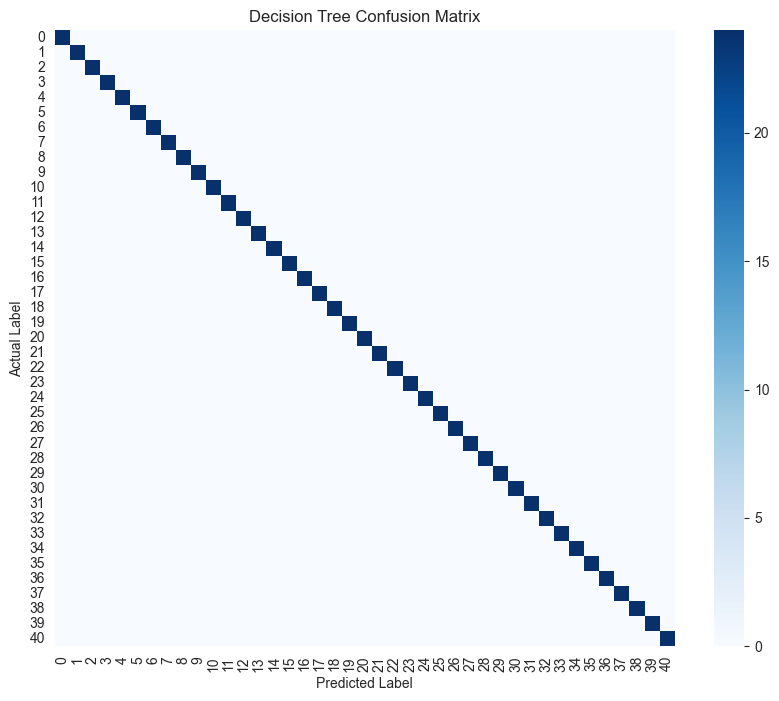

In [21]:
cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    cbar=True
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8.2 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. It is widely used for disease prediction because of its robustness and high classification performance.

In [23]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy : 100.0 %


In [24]:
### Random Forest Classification Report
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

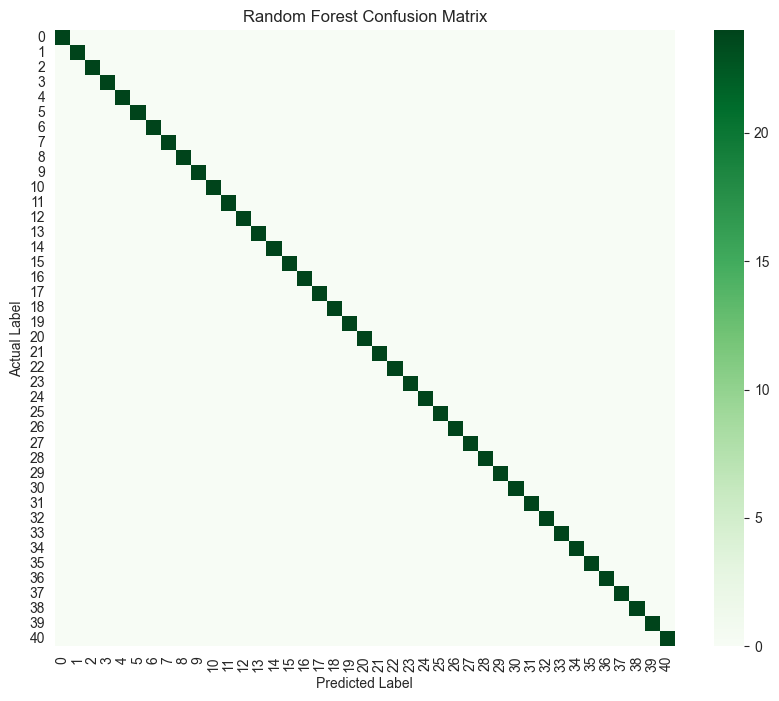

In [25]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Greens",
    cbar=True
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8.3 K-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm is a supervised machine learning technique that classifies a data point based on the majority class among its nearest neighbors. It is simple, effective, and performs well for many classification problems.

In [27]:
# Train K-Nearest Neighbors Classifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy :", round(knn_accuracy * 100, 2), "%")

KNN Accuracy : 100.0 %


### KNN Classification Report

In [28]:
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

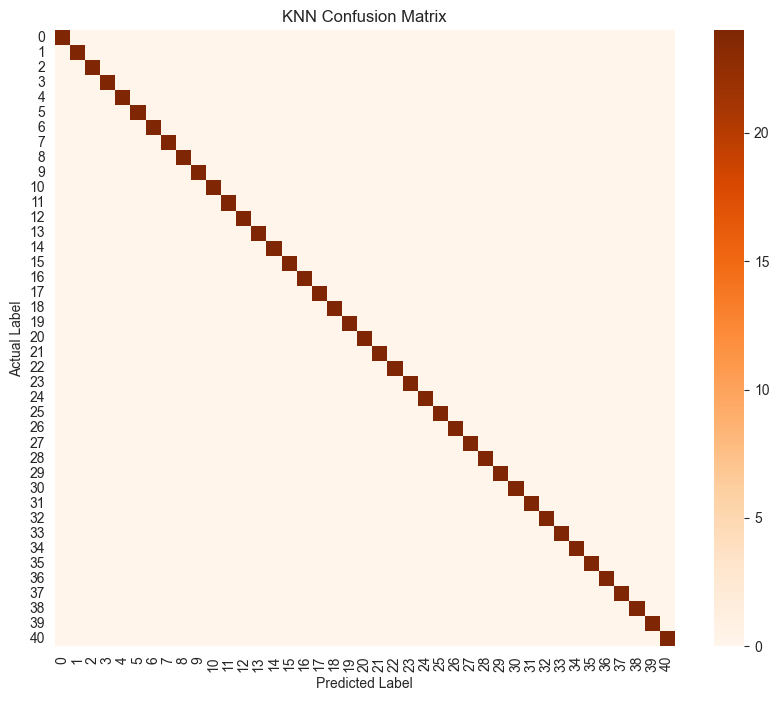

In [29]:
cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Oranges",
    cbar=True
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8.4 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification tasks. It works by identifying the optimal hyperplane that separates different disease classes while maximizing the margin between them.

In [30]:
# Train Support Vector Machine Classifier

svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy :", round(svm_accuracy * 100, 2), "%")

SVM Accuracy : 100.0 %


### SVM Classification Report


In [31]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

### SVM Confusion Matrix

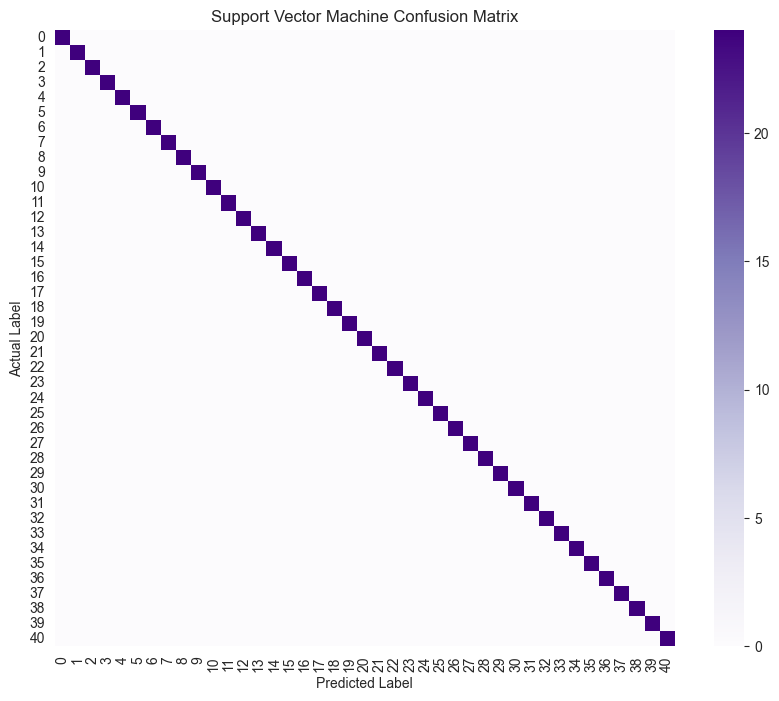

In [32]:
cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Purples",
    cbar=True
)

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8.5 Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It assumes that the features are independent of each other and follows a Gaussian (normal) distribution. Due to its simplicity and fast computation, it is widely used for classification tasks.

In [33]:
# Train Gaussian Naive Bayes Classifier

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Gaussian Naive Bayes Accuracy :", round(nb_accuracy * 100, 2), "%")

Gaussian Naive Bayes Accuracy : 100.0 %


### Gaussian Naive Bayes Classification Report


In [34]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

### Gaussian Naive Bayes Confusion Matrix

The confusion matrix provides a visual representation of the prediction results obtained using the Gaussian Naive Bayes classifier.

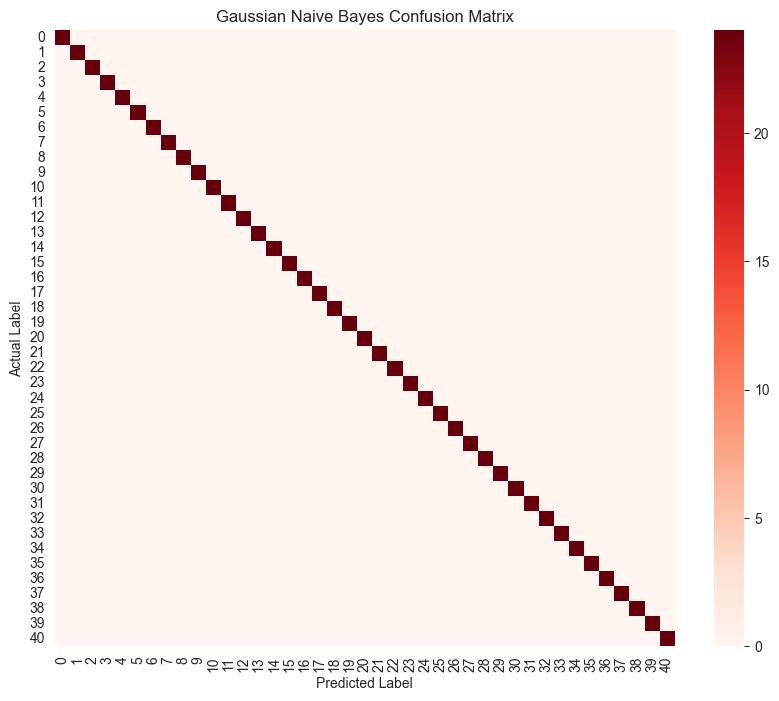

In [36]:
cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Reds",
    cbar=True
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8.6 Logistic Regression


In [37]:
# Train Logistic Regression Classifier

lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy :", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy : 100.0 %


In [38]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24
          17       1.00    

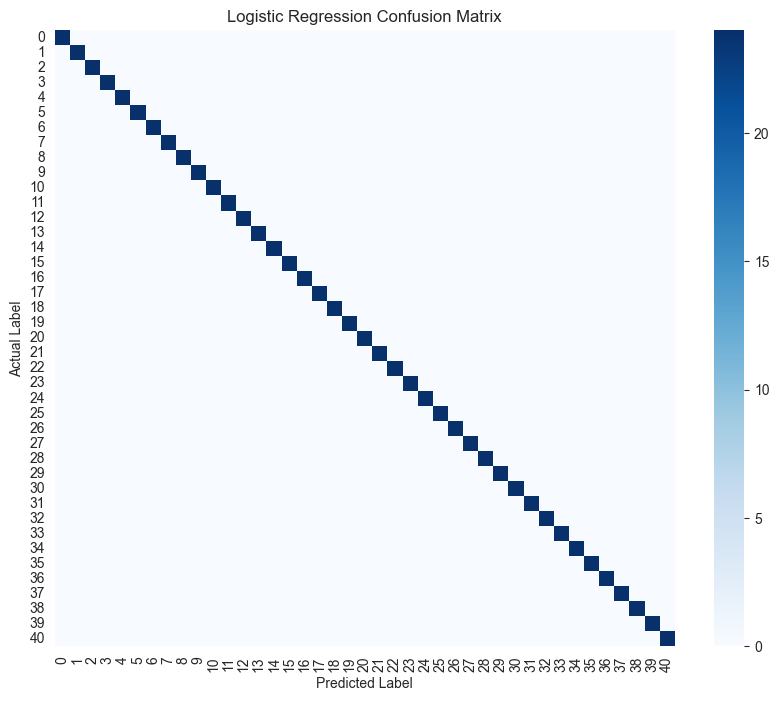

In [39]:
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    cbar=True
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 9. Model Performance Comparison

The performance of all trained machine learning models is compared using their classification accuracy. The model with the highest accuracy is selected for deployment in the disease prediction system.

In [41]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Gaussian Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy,
        nb_accuracy,
        lr_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy,Accuracy (%)
0,Decision Tree,1.0,100.0
1,Random Forest,1.0,100.0
2,K-Nearest Neighbors,1.0,100.0
3,Support Vector Machine,1.0,100.0
4,Gaussian Naive Bayes,1.0,100.0
5,Logistic Regression,1.0,100.0


## 10. Model Accuracy Comparison

A bar chart is plotted to compare the accuracy of all trained machine learning models. This visualization makes it easier to identify the best-performing classifier.

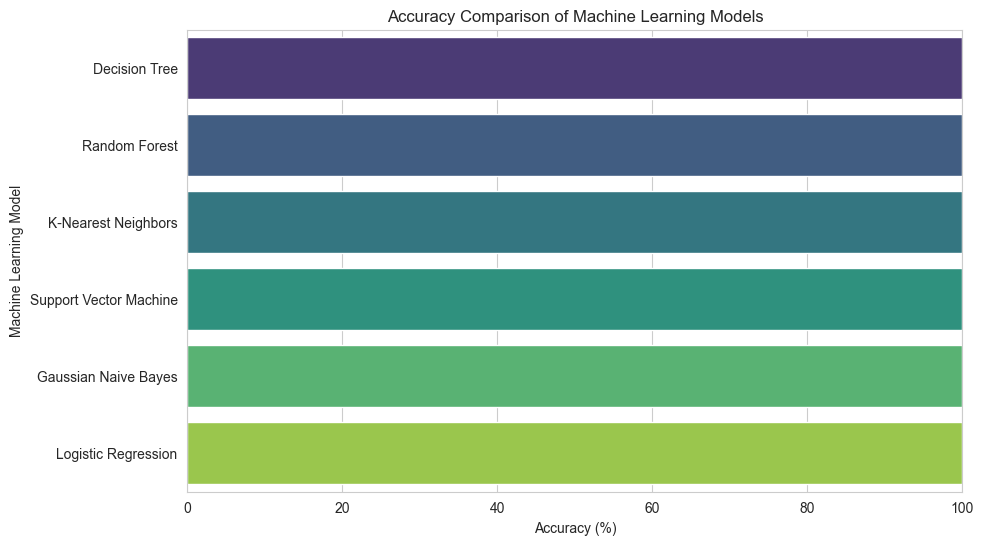

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Accuracy (%)",
    y="Model",
    palette="viridis"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(0,100)

plt.show()

## 11. Best Model Selection

The model with the highest classification accuracy is selected as the final prediction model. This model will be saved and integrated into the disease prediction system during the deployment phase.

In [43]:
best_model_name = results.iloc[0]["Model"]
best_accuracy = results.iloc[0]["Accuracy (%)"]

print("Best Performing Model :", best_model_name)
print("Accuracy :", round(best_accuracy,2), "%")

Best Performing Model : Decision Tree
Accuracy : 100.0 %


## 12. Save the Best Model

In [44]:
# Select the trained model based on the best result

model_dict = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Gaussian Naive Bayes": nb_model,
    "Logistic Regression": lr_model
}

best_model = model_dict[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully as 'best_model.pkl'")

Best model saved successfully as 'best_model.pkl'


# Conclusion

In this ticket, multiple machine learning classification algorithms were developed and evaluated using the processed symptom dataset prepared in Ticket 1. The models were assessed using classification accuracy, confusion matrices, and classification reports.

Among all the trained models, the best-performing classifier was selected based on its accuracy and saved for future deployment. The trained model will be integrated into the Flask-based Disease Prediction System in the next development phase (Ticket 3), enabling accurate disease prediction and AI-powered health recipe recommendations.

In [45]:
import os

print("Exists:", os.path.exists("best_model.pkl"))
print("Size:", os.path.getsize("best_model.pkl"), "bytes")

Exists: True
Size: 59425 bytes
